# Laboratorio 7-2

## Etapa 2: Probabilidad de completar el álbum según el número de sobres

En esta etapa se trabaja con el álbum reducido usado en la simulación inicial: `N = 100` estampas distintas y `S = 7` estampas por sobre. Para cada valor fijo de `M` se simulan `R = 10000` compras de exactamente `M` sobres y se estima la probabilidad de que el álbum esté completo al final.

Todas las simulaciones usan la semilla `2026` para reproducibilidad.


In [9]:
import numpy as np
import matplotlib.pyplot as plt

SEMILLA = 2026
N = 100       # estampas diferentes en el álbum reducido
S = 7         # estampas por sobre
R = 10_000    # número de simulaciones
M_VALORES = np.array([20, 25, 30, 35, 40, 45, 50, 60, 70, 80])

rng = np.random.default_rng(SEMILLA)


## Simulación inicial: sobres necesarios para completar

Primero se repite la simulación hasta completar el álbum. Esto permite comparar el valor de `M` asociado a una probabilidad cercana al 50 % con la mediana del número de sobres necesarios.


In [10]:
def simular_hasta_completar(n, s, rng):
    """Devuelve el número de sobres y de repetidas hasta completar el álbum."""
    coleccion = np.zeros(n, dtype=bool)
    sobres = 0
    repetidas = 0

    while not coleccion.all():
        sobre = rng.choice(n, size=s, replace=False)
        repetidas += coleccion[sobre].sum()
        coleccion[sobre] = True
        sobres += 1

    return sobres, int(repetidas)


resultados_sobres = np.empty(R, dtype=int)
resultados_repetidas = np.empty(R, dtype=int)

for i in range(R):
    resultados_sobres[i], resultados_repetidas[i] = simular_hasta_completar(N, S, rng)

media_sobres = resultados_sobres.mean()
mediana_sobres = np.median(resultados_sobres)
std_sobres = resultados_sobres.std(ddof=1)

H_N = np.sum(1 / np.arange(1, N + 1))
valor_teorico = (N / S) * H_N

print(f"Media simulada de sobres: {media_sobres:.3f}")
print(f"Mediana simulada de sobres: {mediana_sobres:.0f}")
print(f"Desviación estándar: {std_sobres:.3f}")
print(f"Aproximación teórica (N/S) H_N: {valor_teorico:.3f}")


Media simulada de sobres: 72.303
Mediana simulada de sobres: 69
Desviación estándar: 17.347
Aproximación teórica (N/S) H_N: 74.105


## Simulación con un número fijo de sobres

Para cada valor de `M`, se compran exactamente `M` sobres. La variable registrada es 1 si el álbum queda completo y 0 si todavía falta al menos una estampa.


In [11]:
def estimar_probabilidades_por_m(n, s, r, m_valores, rng):
    """Estima P(completar | M sobres) para varios valores de M."""
    m_valores = np.array(m_valores)
    colecciones = np.zeros((r, n), dtype=bool)
    filas = np.arange(r)[:, None]
    probabilidades = []
    checkpoints = set(m_valores.tolist())

    for m in range(1, m_valores.max() + 1):
        # Cada fila representa un sobre para una simulación distinta.
        sobres = np.argpartition(rng.random((r, n)), s - 1, axis=1)[:, :s]
        colecciones[filas, sobres] = True

        if m in checkpoints:
            probabilidades.append(colecciones.all(axis=1).mean())

    return np.array(probabilidades)


probabilidades = estimar_probabilidades_por_m(N, S, R, M_VALORES, rng)

# Aproximaciones teóricas basadas en P(no obtener una estampa específica) ≈ exp(-MS/N).
prob_no_especifica = np.exp(-M_VALORES * S / N)
faltantes_esperadas = N * prob_no_especifica
prob_completar_independencia = (1 - prob_no_especifica) ** N
prob_completar_poisson = np.exp(-faltantes_esperadas)


In [12]:
encabezado = (
    f"{'M':>5} | {'P simulada':>11} | {'E[faltantes]':>12} | "
    f"{'P teoría ind.':>13} | {'P Poisson':>9}"
)
print(encabezado)
print("-" * len(encabezado))

for m, p, falt, p_ind, p_pois in zip(
    M_VALORES,
    probabilidades,
    faltantes_esperadas,
    prob_completar_independencia,
    prob_completar_poisson,
):
    print(f"{m:5d} | {p:11.4f} | {falt:12.2f} | {p_ind:13.4f} | {p_pois:9.4f}")


    M |  P simulada | E[faltantes] | P teoría ind. | P Poisson
--------------------------------------------------------------
   20 |      0.0000 |        24.66 |        0.0000 |    0.0000
   25 |      0.0000 |        17.38 |        0.0000 |    0.0000
   30 |      0.0000 |        12.25 |        0.0000 |    0.0000
   35 |      0.0000 |         8.63 |        0.0001 |    0.0002
   40 |      0.0018 |         6.08 |        0.0019 |    0.0023
   45 |      0.0139 |         4.29 |        0.0125 |    0.0138
   50 |      0.0572 |         3.02 |        0.0466 |    0.0488
   60 |      0.2625 |         1.50 |        0.2207 |    0.2232
   70 |      0.5266 |         0.74 |        0.4736 |    0.4749
   80 |      0.7353 |         0.37 |        0.6904 |    0.6909


## Visualización

La línea horizontal marca la probabilidad 0.5. El primer valor de `M` cuya barra queda por encima de esa línea es el primer presupuesto de sobres, dentro de la lista estudiada, que da al menos 50 % de éxito.


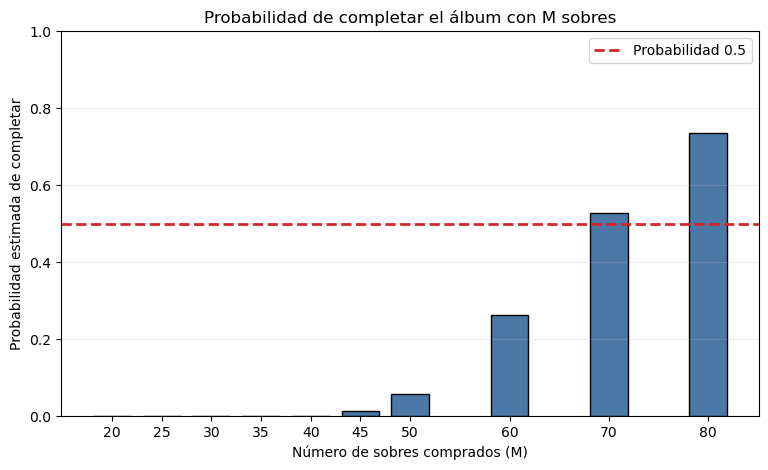

In [13]:
plt.figure(figsize=(9, 5))
plt.bar(M_VALORES, probabilidades, width=3.8, color="#4C78A8", edgecolor="black")
plt.axhline(0.5, color="#D62728", linestyle="--", linewidth=2, label="Probabilidad 0.5")
plt.ylim(0, 1)
plt.xticks(M_VALORES)
plt.xlabel("Número de sobres comprados (M)")
plt.ylabel("Probabilidad estimada de completar")
plt.title("Probabilidad de completar el álbum con M sobres")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()


## Preguntas de análisis

**1. ¿Para qué valor de M la probabilidad estimada supera por primera vez el 50 %? ¿Y el 90 %?**

Con la semilla 2026 y `R = 10000`, las probabilidades simuladas son aproximadamente:

| M | Probabilidad estimada |
|---:|---:|
| 20 | 0.0000 |
| 25 | 0.0000 |
| 30 | 0.0000 |
| 35 | 0.0000 |
| 40 | 0.0018 |
| 45 | 0.0139 |
| 50 | 0.0572 |
| 60 | 0.2625 |
| 70 | 0.5266 |
| 80 | 0.7353 |

La probabilidad supera por primera vez el 50 % en `M = 70`. En los valores dados no supera el 90 %; para estimar ese punto habría que ampliar la secuencia a valores mayores que 80.

**2. Comparar el valor de M que da una probabilidad del 50 % con la mediana del número de sobres necesarios. ¿Son similares? ¿Por qué?**

La mediana simulada del número de sobres necesarios fue `69`. El primer valor de la tabla con probabilidad mayor a 50 % fue `M = 70`, así que son prácticamente iguales. Esto ocurre porque `P(completar con M sobres)` es la función de distribución acumulada del número de sobres necesarios para completar el álbum: cuando esa probabilidad cruza 0.5, se está localizando la mediana.

**3. Uso de la aproximación** `exp(-MS/N)`

La cantidad `exp(-MS/N)` aproxima la probabilidad de que una estampa específica no haya aparecido después de `M` sobres. Multiplicando por `N` se obtiene una aproximación del número esperado de estampas faltantes. Por ejemplo, para `M = 70`, se espera que falten aproximadamente `100 exp(-70·7/100) = 0.74` estampas. Para `M = 80`, esta esperanza baja a `0.37`, pero todavía hay una probabilidad no despreciable de que falte alguna; por eso la probabilidad simulada de completar aún no llega al 90 %.


In [14]:
def primer_m_que_supera(m_valores, probabilidades, umbral):
    indices = np.flatnonzero(probabilidades >= umbral)
    return None if len(indices) == 0 else int(m_valores[indices[0]])


m_50 = primer_m_que_supera(M_VALORES, probabilidades, 0.50)
m_90 = primer_m_que_supera(M_VALORES, probabilidades, 0.90)

print(f"Primer M con probabilidad >= 50 %: {m_50}")
print(f"Primer M con probabilidad >= 90 %: {m_90}")
print(f"Mediana simulada de sobres necesarios: {mediana_sobres:.0f}")


Primer M con probabilidad >= 50 %: 70
Primer M con probabilidad >= 90 %: None
Mediana simulada de sobres necesarios: 69
